In [0]:
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from delta.tables import DeltaTable
import matplotlib.pyplot as plt

In [0]:
base_path = "file:/Workspace/Users/azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com"

patients_df =spark.read.csv(f"{base_path}/patients.csv", header=True)

doctors_df =spark.read.csv(f"{base_path}/doctors.csv", header=True)

appointments_df =spark.read.csv(f"{base_path}/appointments.csv", header=True)

patient_preferences_df = spark.read.option("multiLine","true").json(f"{base_path}/patient_preferences.json")

In [0]:
patients_df.printSchema()
doctors_df.printSchema()
appointments_df.printSchema()
patient_preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: string (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: string (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: string (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospital

In [0]:
patients_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/patients")

doctors_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/doctors")

appointments_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/appoointments")

patient_preferences_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/patient_preferences")

In [0]:
patients_df.show()
doctors_df.show()
appointments_df.show()
patient_preferences_df.show(truncate=False)

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| 

In [0]:
flat_df=patient_preferences_df.select("patient_id","preferred_hospital", "contact.phone", "contact.email")
flat_df.show()

+----------+------------------+----------+--------------+
|patient_id|preferred_hospital|     phone|         email|
+----------+------------------+----------+--------------+
|      P101|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102|  Yashoda Hospital|9876500012|priya@mail.com|
|      P104|     Care Hospital|9876500014|sneha@mail.com|
|      P108|   Apollo Hospital|9876500018|meera@mail.com|
+----------+------------------+----------+--------------+



In [0]:
patient_pref_df= patients_df.join(
    flat_df,"patient_id","left"
)
patient_pref_df.show()

+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|              NULL|      NULL|          NULL|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|     Care Hospital|9876500014|sneha@mail.com|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|              NULL|      NULL|          NULL|
|      P106|  Neha Singh|     Pu

In [0]:
patient_appoint_df= patient_pref_df.join(
    appointments_df,"patient_id","left"
)
patient_appoint_df.show()

+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+--------------+---------+----------------+--------------+-----------+---------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|appointment_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+--------------+---------+----------------+--------------+-----------+---------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|         A1009|     D106|      2026-06-05|Cardiac Review|       6500|Completed|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|         A1002|     D102|      2026-06-01|      Migraine|       3500|Completed|


In [0]:
Hospital_df=patient_appoint_df.join(
    doctors_df,"doctor_id","left"
)

Hospital_df.display()

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,city,consultation_fee
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500


In [0]:
Hospital_df=Hospital_df.na.fill(
    {
        "phone":"Not Provided",
        "email":"Not Provided",
        "preferred_hospital":"Unknown"
    }
)

Hospital_df.display()

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,city,consultation_fee
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Unknown,Not Provided,Not Provided,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Unknown,Not Provided,Not Provided,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Unknown,Not Provided,Not Provided,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Unknown,Not Provided,Not Provided,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500


In [0]:
Hospital_df=Hospital_df.withColumn(
    "final_bill",(col("bill_amount").cast("float") + col("consultation_fee").cast("float"))
).withColumn("appointment_month",month("appointment_date")).withColumn(
    "patient_age_group",when(col("age")>=50,"Senior").when(col("age")>=30,"Adult").otherwise("Young")
)

Hospital_df.display()

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500.0,6,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500.0,6,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Unknown,Not Provided,Not Provided,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000.0,6,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000.0,6,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Unknown,Not Provided,Not Provided,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700.0,6,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Unknown,Not Provided,Not Provided,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000.0,6,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Unknown,Not Provided,Not Provided,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000.0,6,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500.0,6,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500.0,6,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500.0,6,Adult


In [0]:
Hospital_df.drop(doctors_df["city"]).write.mode("overwrite").format("delta").save("dbfs:/silver/hospital")


In [0]:
Hospital_df.createOrReplaceTempView("hospital")

In [0]:
spark.sql(''' select sum(final_bill) from hospital''').show()

+---------------+
|sum(final_bill)|
+---------------+
|        69200.0|
+---------------+



In [0]:
spark.sql('''select department,sum(final_bill) from hospital
          group by department''').show()

+-----------+---------------+
| department|sum(final_bill)|
+-----------+---------------+
|Orthopedics|        21500.0|
| Cardiology|        33000.0|
| Pediatrics|         2700.0|
|Dermatology|         6500.0|
|  Neurology|         5500.0|
+-----------+---------------+



In [0]:
spark.sql('''select city, sum(final_bill)from hospital
group by city''').show()

+---------+---------------+
|     city|sum(final_bill)|
+---------+---------------+
|    Delhi|        21500.0|
|  Chennai|         2700.0|
|    Kochi|         3500.0|
|Hyderabad|        23000.0|
|Bangalore|         5500.0|
|     Pune|        10000.0|
|   Mumbai|         3000.0|
+---------+---------------+



In [0]:
spark.sql('''select * from hospital
         where status ="Completed"''').display()

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,3000,9500.0,6,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,2000,5500.0,6,Young
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,2500,14500.0,6,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Unknown,Not Provided,Not Provided,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,1200,2700.0,6,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Unknown,Not Provided,Not Provided,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,3000,10000.0,6,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Unknown,Not Provided,Not Provided,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,1500,7000.0,6,Young
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,1500,6500.0,6,Adult


In [0]:
spark.sql("""SELECT patient_name,SUM(final_bill) billing FROM hospital GROUP BY patient_name ORDER BY billing DESC""").show()


+------------+-------+
|patient_name|billing|
+------------+-------+
| Sneha Patel|21500.0|
|Rahul Sharma|16000.0|
|  Neha Singh|10000.0|
| Arjun Verma| 7000.0|
| Priya Reddy| 5500.0|
|  Meera Nair| 3500.0|
|  Amit Kumar| 3000.0|
|  Farhan Ali| 2700.0|
+------------+-------+



In [0]:
doctor_rev=Hospital_df.groupBy("doctor_name").agg(sum("final_bill").alias("revenue"))
w=Window.orderBy(desc("revenue"))
doctor_rev.withColumn("rank",rank().over(w)).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+----+
|doctor_name|revenue|rank|
+-----------+-------+----+
| Dr. Suresh|21500.0|   1|
|  Dr. Kiran|19500.0|   2|
| Dr. Ramesh|13500.0|   3|
|  Dr. Anita| 6500.0|   4|
|  Dr. Priya| 5500.0|   5|
|  Dr. Meera| 2700.0|   6|
+-----------+-------+----+



In [0]:
dept_rev=Hospital_df.groupBy("department").agg(sum("final_bill").alias("revenue"))
dept_rev.withColumn("rank",rank().over(w)).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+----+
| department|revenue|rank|
+-----------+-------+----+
| Cardiology|33000.0|   1|
|Orthopedics|21500.0|   2|
|Dermatology| 6500.0|   3|
|  Neurology| 5500.0|   4|
| Pediatrics| 2700.0|   5|
+-----------+-------+----+



In [0]:
patient_bill=Hospital_df.groupBy("patient_name").agg(sum("final_bill").alias("billing"))

patient_bill.withColumn("rank",rank().over(Window.orderBy(desc("billing")))).filter("rank<=3").show()



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+-------+----+
|patient_name|billing|rank|
+------------+-------+----+
| Sneha Patel|21500.0|   1|
|Rahul Sharma|16000.0|   2|
|  Neha Singh|10000.0|   3|
+------------+-------+----+



In [0]:
wd=Window.partitionBy("department").orderBy(desc("final_bill"))

Hospital_df.withColumn("rank",rank().over(wd)).filter("rank=1").display()

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,city,consultation_fee,final_bill,appointment_month,patient_age_group,rank
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Unknown,Not Provided,Not Provided,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000.0,6,Adult,1
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500.0,6,Adult,1
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500.0,6,Young,1
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500.0,6,Adult,1
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Unknown,Not Provided,Not Provided,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700.0,6,Senior,1


In [0]:
wr=Window.orderBy("appointment_date")
Hospital_df.withColumn("running_revenue",sum("final_bill").over(wr)).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+----------+------------+---------+-----------+---+------+----------------+------------------+------------+--------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+---------+----------------+----------+-----------------+-----------------+---------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|       phone|         email|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|     city|consultation_fee|final_bill|appointment_month|patient_age_group|running_revenue|
+---------+----------+------------+---------+-----------+---+------+----------------+------------------+------------+--------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+---------+----------------+----------+-----------------+-----------------+---------------+
|     D102|      P102| Priya Reddy|Bangalore|  Karna

In [0]:
Hospital_df.drop(doctors_df["city"]).write.mode("overwrite").format("delta").save("dbfs:/delta/hospitals")

In [0]:
Hospital_df.drop(doctors_df["city"]).write.mode("overwrite").format("delta").saveAsTable("hospital_table")

In [0]:
%sql DESCRIBE HISTORY hospital_table;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T12:00:19.000Z,148916151530801,azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4449026334936747),15baceef-08a1-478e-a66f-073903c5e4f8,0622-072159-yoc5zf8l-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 6906)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
spark.read.format("delta").option("versionAsOf",0).load("dbfs:/delta/hospitals").show()


+---------+----------+------------+---------+-----------+---+------+----------------+------------------+------------+--------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|       phone|         email|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+------------+---------+-----------+---+------+----------------+------------------+------------+--------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|  9876500011|rahul@mail.co

In [0]:
updated_patients = spark.createDataFrame(
[
("P101","Rahul Sharma","Bangalore","Karnataka","35","Male","Active"),
("P106","Neha Singh","Hyderabad","Telangana","38","Female","Active")
],
[
"patient_id",
"patient_name",
"city",
"state",
"age",
"gender",
"insurance_status"
]
)

delta_table = DeltaTable.forPath(
    spark,
    "dbfs:/delta/hospitals"
)

delta_table.alias("target") \
.merge(
    updated_patients.alias("source"),
    "target.patient_id = source.patient_id"
) \
.whenMatchedUpdate(
    set={
        "city":"source.city",
        "state":"source.state",
        "insurance_status":"source.insurance_status"
    }
) \
.execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql DESCRIBE HISTORY hospital_table;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T12:00:19.000Z,148916151530801,azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4449026334936747),15baceef-08a1-478e-a66f-073903c5e4f8,0622-072159-yoc5zf8l-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 6906)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql OPTIMIZE hospital_table;

path,metrics
abfss://unity-catalog-storage@dbstoragedaqeulmliu5fu.dfs.core.windows.net/7405614176101619/__unitystorage/catalogs/e4fa79a1-fc33-4aad-bcae-881d69b5f5ad/tables/23c4ec7d-29b3-47f3-ad3e-e996fb2f1063,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782129959342, 1782129959774, 8, 0, null, List(0, 0), null, 22, 22, 0, 0, null, null)"


In [0]:
%sql OPTIMIZE hospital_table
ZORDER BY(patient_id);

path,metrics
abfss://unity-catalog-storage@dbstoragedaqeulmliu5fu.dfs.core.windows.net/7405614176101619/__unitystorage/catalogs/e4fa79a1-fc33-4aad-bcae-881d69b5f5ad/tables/23c4ec7d-29b3-47f3-ad3e-e996fb2f1063,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 6906), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782130033778, 1782130034263, 8, 0, null, List(0, 0), null, 22, 22, 0, 0, null, null)"


In [0]:
%sql VACUUM hospital_table RETAIN 168 HOURS;

path
abfss://unity-catalog-storage@dbstoragedaqeulmliu5fu.dfs.core.windows.net/7405614176101619/__unitystorage/catalogs/e4fa79a1-fc33-4aad-bcae-881d69b5f5ad/tables/23c4ec7d-29b3-47f3-ad3e-e996fb2f1063


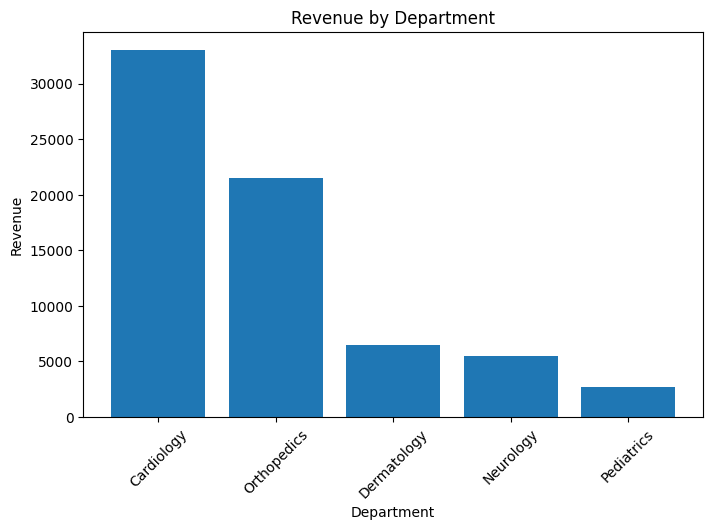

In [0]:
department_revenue = Hospital_df.groupBy("department").agg(
    sum("final_bill").alias("total_revenue")
).orderBy("total_revenue", ascending=False)

dept_pd = department_revenue.toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_pd["department"], dept_pd["total_revenue"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

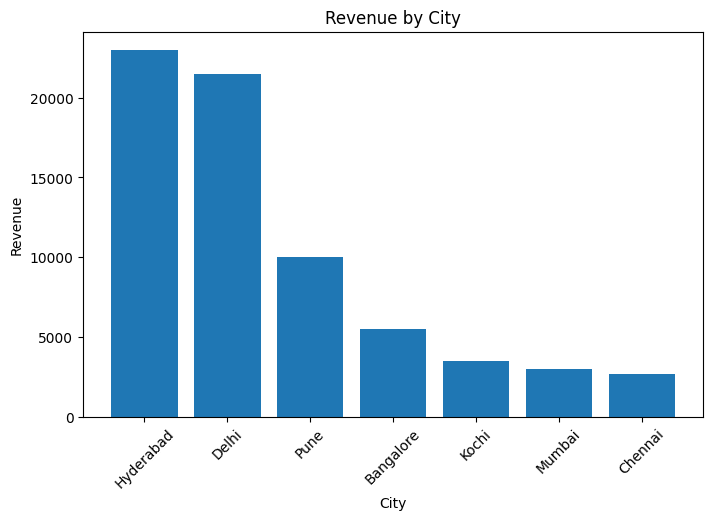

In [0]:
city_revenue = Hospital_df.drop(doctors_df["city"]).groupBy("city").agg(
    sum("final_bill").alias("total_revenue")
).orderBy("total_revenue", ascending=False)

city_pd = city_revenue.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

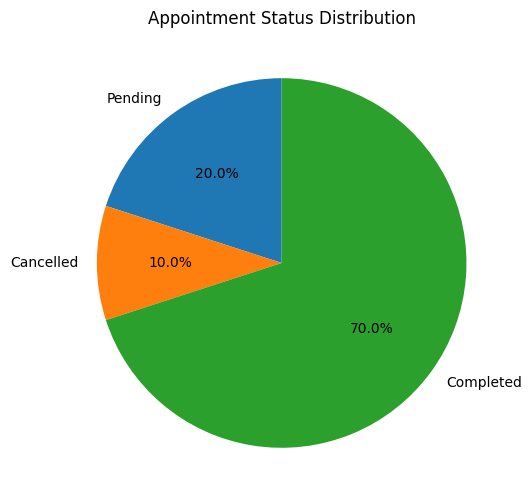

In [0]:
status_df = Hospital_df.groupBy("status").count()

status_pd = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Appointment Status Distribution")
plt.show()

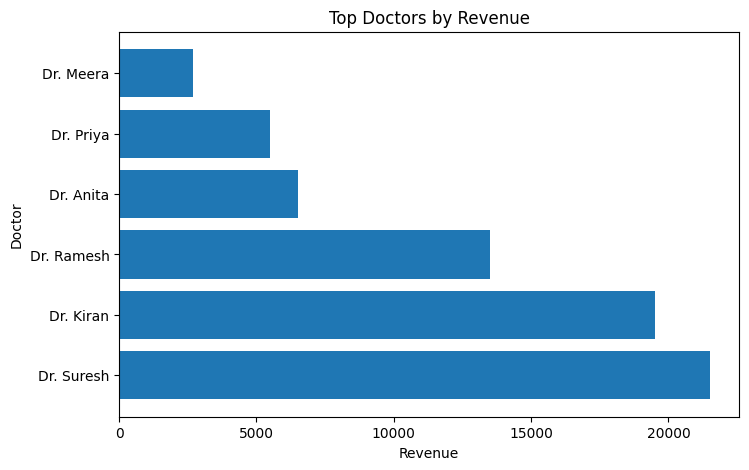

In [0]:
doctor_revenue = Hospital_df.groupBy("doctor_name").agg(
    sum("final_bill").alias("total_revenue")
).orderBy("total_revenue", ascending=False)

doctor_pd = doctor_revenue.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    doctor_pd["doctor_name"],
    doctor_pd["total_revenue"]
)

plt.title("Top Doctors by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Doctor")
plt.show()

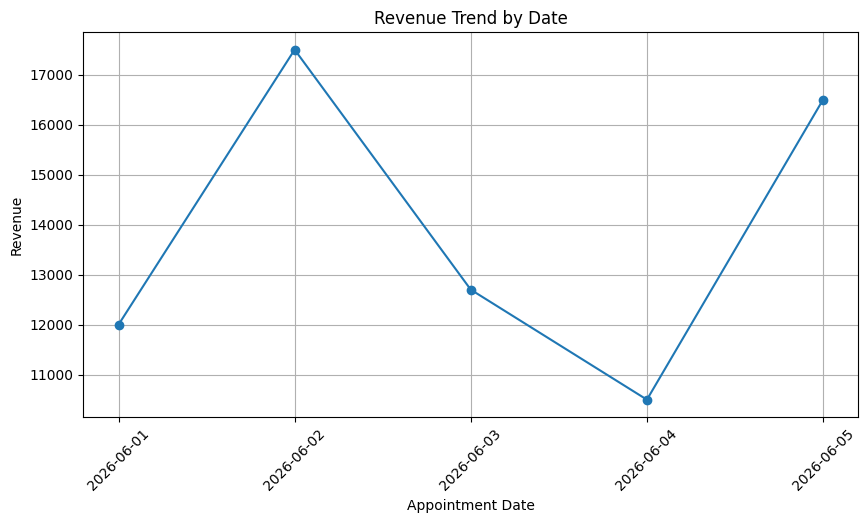

In [0]:
daily_revenue = Hospital_df.groupBy("appointment_date").agg(
    sum("final_bill").alias("daily_revenue")
).orderBy("appointment_date")

daily_pd = daily_revenue.toPandas()

plt.figure(figsize=(10,5))
plt.plot(
    daily_pd["appointment_date"],
    daily_pd["daily_revenue"],
    marker="o"
)

plt.title("Revenue Trend by Date")
plt.xlabel("Appointment Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [0]:
Hospital_df.drop(doctors_df["city"]).write.mode("overwrite").saveAsTable("Managed_Table")

In [0]:
Hospital_df.createOrReplaceTempView("healthcare_temp")

In [0]:
Hospital_df.createOrReplaceTempView("healthcare_global")